# Credit Card Fraud Detection — Exploratory Data Analysis

This notebook explores the Credit Card Fraud Detection dataset. The dataset is highly imbalanced because only a very small percentage of transactions are fraudulent.

The dataset contains 284,807 transactions and 31 columns. The target column is `Class`, where:

- `0` = Legitimate transaction
- `1` = Fraud transaction

The main goal of this notebook is to understand the dataset, check data quality, analyze class imbalance, and identify useful patterns before cleaning and model building.


In [36]:
import sys
print(sys.executable)

c:\Users\hirun\Desktop\credit-card-fraud-detection\venv\Scripts\python.exe


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Notebook kernel is working correctly")

Notebook kernel is working correctly


## 1. Imports & Load Data

We load the standard data science libraries, import the helper function from `utils.py`, and load the raw dataset from the `data` folder.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add current project folder to Python path so we can import utils.py
sys.path.append(".")

from utils import load_data

# Set chart style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = load_data("data/creditcard.csv")

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

df.head()

Dataset loaded: 284,807 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [39]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [40]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 284807
Number of columns: 31


In [41]:
display(df.head())
display(df.tail())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


## 2. Dataset Overview

We inspect the structure of the dataset, check data types, identify missing values, detect duplicate rows, and analyze the distribution of the target variable `Class`.

`V1`–`V28` are anonymized PCA components, `Time` represents seconds since the first transaction, `Amount` is the transaction amount, and `Class` is the binary target variable where `0` means legitimate and `1` means fraud.


In [42]:
print("Dataset Shape")
print("-------------")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names")
print("------------")
print(df.columns.tolist())

print("\nData Types")
print("----------")
print(df.dtypes)

Dataset Shape
-------------
Rows    : 284,807
Columns : 31

Column Names
------------
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types
----------
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [43]:
missing_values = df.isnull().sum()

print("Missing Values per Column")
print("-------------------------")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values per Column
-------------------------
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total Missing Values: 0


In [44]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows")
print("--------------")
print(f"Number of duplicate rows: {duplicate_count:,}")

Duplicate Rows
--------------
Number of duplicate rows: 1,081


## 3. Class Distribution

The class imbalance is very severe. Only about 0.17% of transactions are fraudulent, while the majority of transactions are legitimate.

Because of this imbalance, accuracy is not a reliable evaluation metric. A model could predict almost all transactions as legitimate and still get very high accuracy. Therefore, we will focus more on Precision, Recall, F1-score, ROC-AUC, and confusion matrix during model evaluation.

Class Counts
------------
Legitimate transactions : 284,315
Fraud transactions      : 492

Class Percentages
-----------------
Legitimate percentage : 99.8273%
Fraud percentage      : 0.1727%


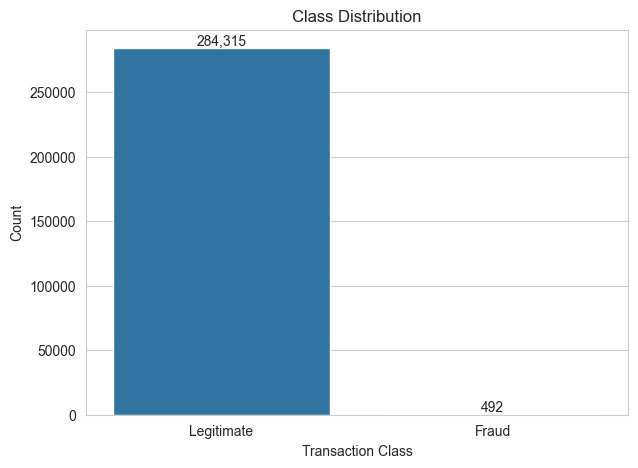

In [45]:
class_counts = df["Class"].value_counts().sort_index()
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

labels = ["Legitimate", "Fraud"]

print("Class Counts")
print("------------")
print(f"Legitimate transactions : {class_counts[0]:,}")
print(f"Fraud transactions      : {class_counts[1]:,}")

print("\nClass Percentages")
print("-----------------")
print(f"Legitimate percentage : {class_percentages[0]:.4f}%")
print(f"Fraud percentage      : {class_percentages[1]:.4f}%")

plt.figure(figsize=(7, 5))
sns.barplot(x=labels, y=class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Count")

for i, count in enumerate(class_counts.values):
    plt.text(i, count, f"{count:,}", ha="center", va="bottom")

plt.show()

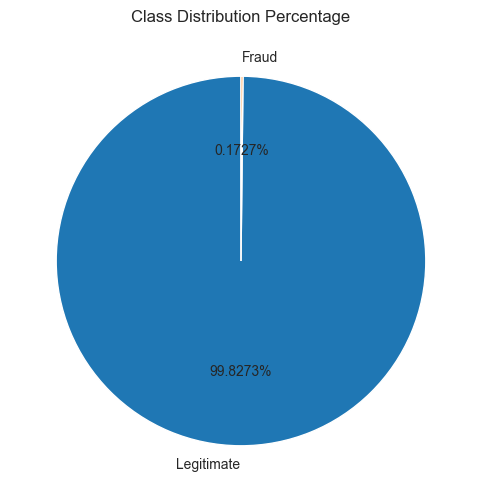

In [46]:
plt.figure(figsize=(6, 6))

plt.pie(
    class_counts.values,
    labels=labels,
    autopct="%1.4f%%",
    startangle=90
)

plt.title("Class Distribution Percentage")
plt.show()

### Interpretation

The dataset is extremely imbalanced. Legitimate transactions represent approximately 99.83% of the dataset, while fraudulent transactions represent only about 0.17%.

This means the model must be evaluated carefully. Accuracy alone is misleading because even a model that predicts every transaction as legitimate would still achieve very high accuracy. For this reason, fraud detection models should be evaluated using Precision, Recall, F1-score, ROC-AUC, and confusion matrix.

## 4. Transaction Amount Analysis

In this section, we analyze the `Amount` and `Time` columns. These are two original features in the dataset.

- `Amount` represents the transaction amount.
- `Time` represents the number of seconds elapsed since the first transaction in the dataset.

This analysis helps us understand whether fraudulent and legitimate transactions show different patterns based on transaction amount and transaction time.

Legitimate transactions: 284315
Fraud transactions: 492


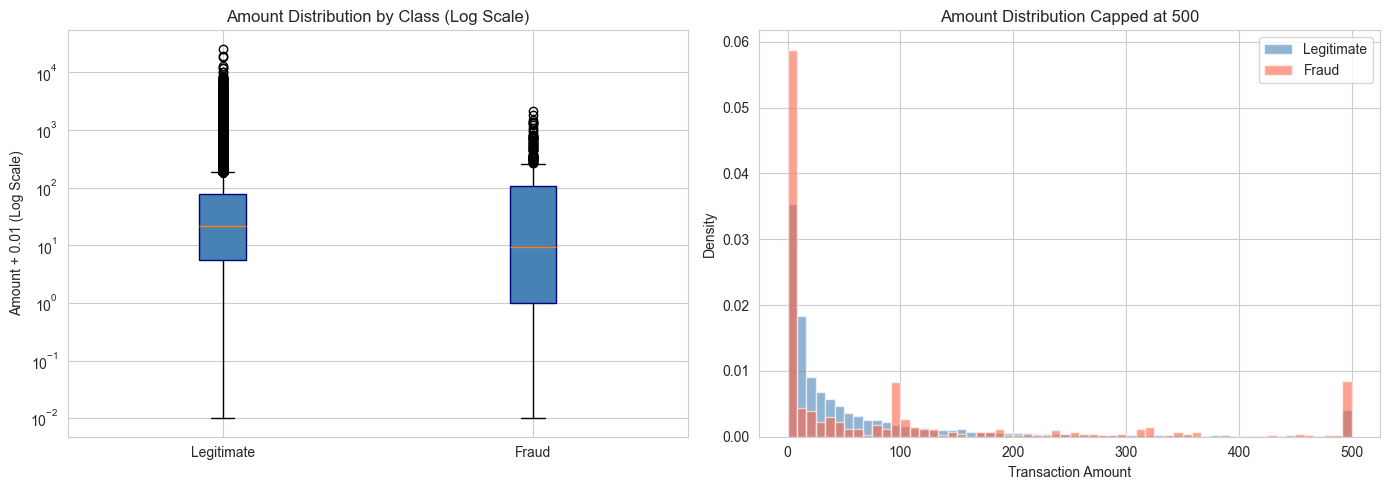

Legitimate Transaction Amount Summary
-------------------------------------
Median Amount : 22.00
Mean Amount   : 88.29
Maximum Amount: 25691.16

Fraud Transaction Amount Summary
--------------------------------
Median Amount : 9.25
Mean Amount   : 122.21
Maximum Amount: 2125.87


In [47]:
# Separate legitimate and fraud transactions
fraud = df[df["Class"] == 1]
legit = df[df["Class"] == 0]

print("Legitimate transactions:", len(legit))
print("Fraud transactions:", len(fraud))

# Create figure with 2 plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Box plot — log scale to handle outliers

# Add a small value to avoid log scale issues with zero amounts
legit_amount_log = legit["Amount"] + 0.01
fraud_amount_log = fraud["Amount"] + 0.01

axes[0].boxplot(
    [legit_amount_log, fraud_amount_log],
    tick_labels=["Legitimate", "Fraud"],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", color="navy")
)

axes[0].set_yscale("log")
axes[0].set_title("Amount Distribution by Class (Log Scale)")
axes[0].set_ylabel("Amount + 0.01 (Log Scale)")



# Overlaid histogram — capped at 500 for readability
cap = 500

axes[1].hist(
    legit["Amount"].clip(upper=cap),
    bins=60,
    alpha=0.6,
    color="steelblue",
    density=True,
    label="Legitimate"
)

axes[1].hist(
    fraud["Amount"].clip(upper=cap),
    bins=60,
    alpha=0.6,
    color="tomato",
    density=True,
    label="Fraud"
)

axes[1].set_title(f"Amount Distribution Capped at {cap}")
axes[1].set_xlabel("Transaction Amount")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()



# Amount statistics

print("Legitimate Transaction Amount Summary")
print("-------------------------------------")
print(f"Median Amount : {legit['Amount'].median():.2f}")
print(f"Mean Amount   : {legit['Amount'].mean():.2f}")
print(f"Maximum Amount: {legit['Amount'].max():.2f}")

print("\nFraud Transaction Amount Summary")
print("--------------------------------")
print(f"Median Amount : {fraud['Amount'].median():.2f}")
print(f"Mean Amount   : {fraud['Amount'].mean():.2f}")
print(f"Maximum Amount: {fraud['Amount'].max():.2f}")

In [48]:
amount_comparison = pd.DataFrame({
    "Transaction Type": ["Legitimate", "Fraud"],
    "Count": [len(legit), len(fraud)],
    "Mean Amount": [legit["Amount"].mean(), fraud["Amount"].mean()],
    "Median Amount": [legit["Amount"].median(), fraud["Amount"].median()],
    "Minimum Amount": [legit["Amount"].min(), fraud["Amount"].min()],
    "Maximum Amount": [legit["Amount"].max(), fraud["Amount"].max()]
})

amount_comparison[["Mean Amount", "Median Amount", "Minimum Amount", "Maximum Amount"]] = amount_comparison[
    ["Mean Amount", "Median Amount", "Minimum Amount", "Maximum Amount"]
].round(2)

display(amount_comparison)

,Transaction Type,Count,Mean Amount,Median Amount,Minimum Amount,Maximum Amount
0,Legitimate,284315,88.29,22.00,0.0,25691.16
1,Fraud,492,122.21,9.25,0.0,2125.87


### Amount Analysis Interpretation

The transaction amount distribution is highly skewed. Most transactions have relatively small amounts, while a few transactions have very large values.

Fraudulent transactions have a lower median amount compared to legitimate transactions. However, transaction amount alone is not enough to identify fraud because both legitimate and fraudulent transactions can occur at low or high amounts.

Therefore, `Amount` may be useful as one feature, but the model must also learn patterns from the PCA-transformed features `V1` to `V28`.

## 5. Time Distribution by Class

`Time` records the number of seconds elapsed since the first transaction in the dataset (covering ~48 hours). We check whether fraudulent transactions concentrate at particular times of day, which could indicate overnight or off-peak fraud patterns.

Legitimate Transaction Time Statistics
-------------------------------------
count    284315.00
mean         26.34
std          13.19
min           0.00
25%          15.06
50%          23.53
75%          38.70
max          48.00
Name: Time, dtype: float64

Fraud Transaction Time Statistics
---------------------------------
count    492.00
mean      22.43
std       13.29
min        0.11
25%       11.46
50%       20.99
75%       35.69
max       47.32
Name: Time, dtype: float64


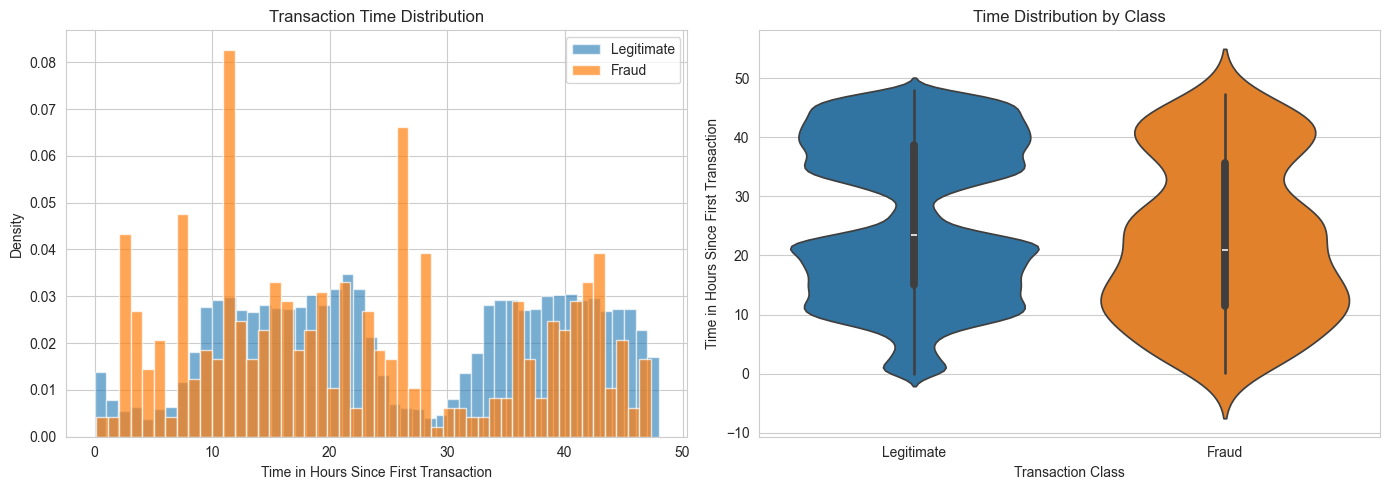

In [49]:
# Convert Time from seconds to hours
legit_time_hours = legit["Time"] / 3600
fraud_time_hours = fraud["Time"] / 3600

print("Legitimate Transaction Time Statistics")
print("-------------------------------------")
print(legit_time_hours.describe().round(2))

print("\nFraud Transaction Time Statistics")
print("---------------------------------")
print(fraud_time_hours.describe().round(2))


# Create time dataframe for violin plot
time_df = pd.DataFrame({
    "Time_hours": df["Time"] / 3600,
    "Class": df["Class"].map({0: "Legitimate", 1: "Fraud"})
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    legit_time_hours,
    bins=48,
    alpha=0.6,
    density=True,
    label="Legitimate"
)

axes[0].hist(
    fraud_time_hours,
    bins=48,
    alpha=0.7,
    density=True,
    label="Fraud"
)

axes[0].set_title("Transaction Time Distribution")
axes[0].set_xlabel("Time in Hours Since First Transaction")
axes[0].set_ylabel("Density")
axes[0].legend()


# Violin plot
sns.violinplot(
    x="Class",
    y="Time_hours",
    hue="Class",
    data=time_df,
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Time Distribution by Class")
axes[1].set_xlabel("Transaction Class")
axes[1].set_ylabel("Time in Hours Since First Transaction")

plt.tight_layout()
plt.show()

### Time Analysis Interpretation

The `Time` feature records the number of seconds elapsed since the first transaction in the dataset. For easier interpretation, it was converted into hours.

The transactions cover approximately 48 hours. Both legitimate and fraudulent transactions are spread across the time period. However, because fraud transactions are very rare compared to legitimate transactions, visual comparison is difficult.

The `Time` feature may still help the model identify transaction behavior patterns, but it must be scaled during preprocessing so that it is on a similar scale to the other numerical features.

## 6. V-Feature Distributions: Fraud vs Legitimate

The V-features are the result of PCA transformation applied by the dataset authors to protect cardholder identity. Even so, several components show clearly separated distributions between classes, indicating strong discriminative power. We visualise the eight most correlated V-features.

Top 8 V-features by |correlation with Class|:
V17    0.3265
V14    0.3025
V12    0.2606
V10    0.2169
V16    0.1965
V3     0.1930
V7     0.1873
V11    0.1549
Name: Class, dtype: float64


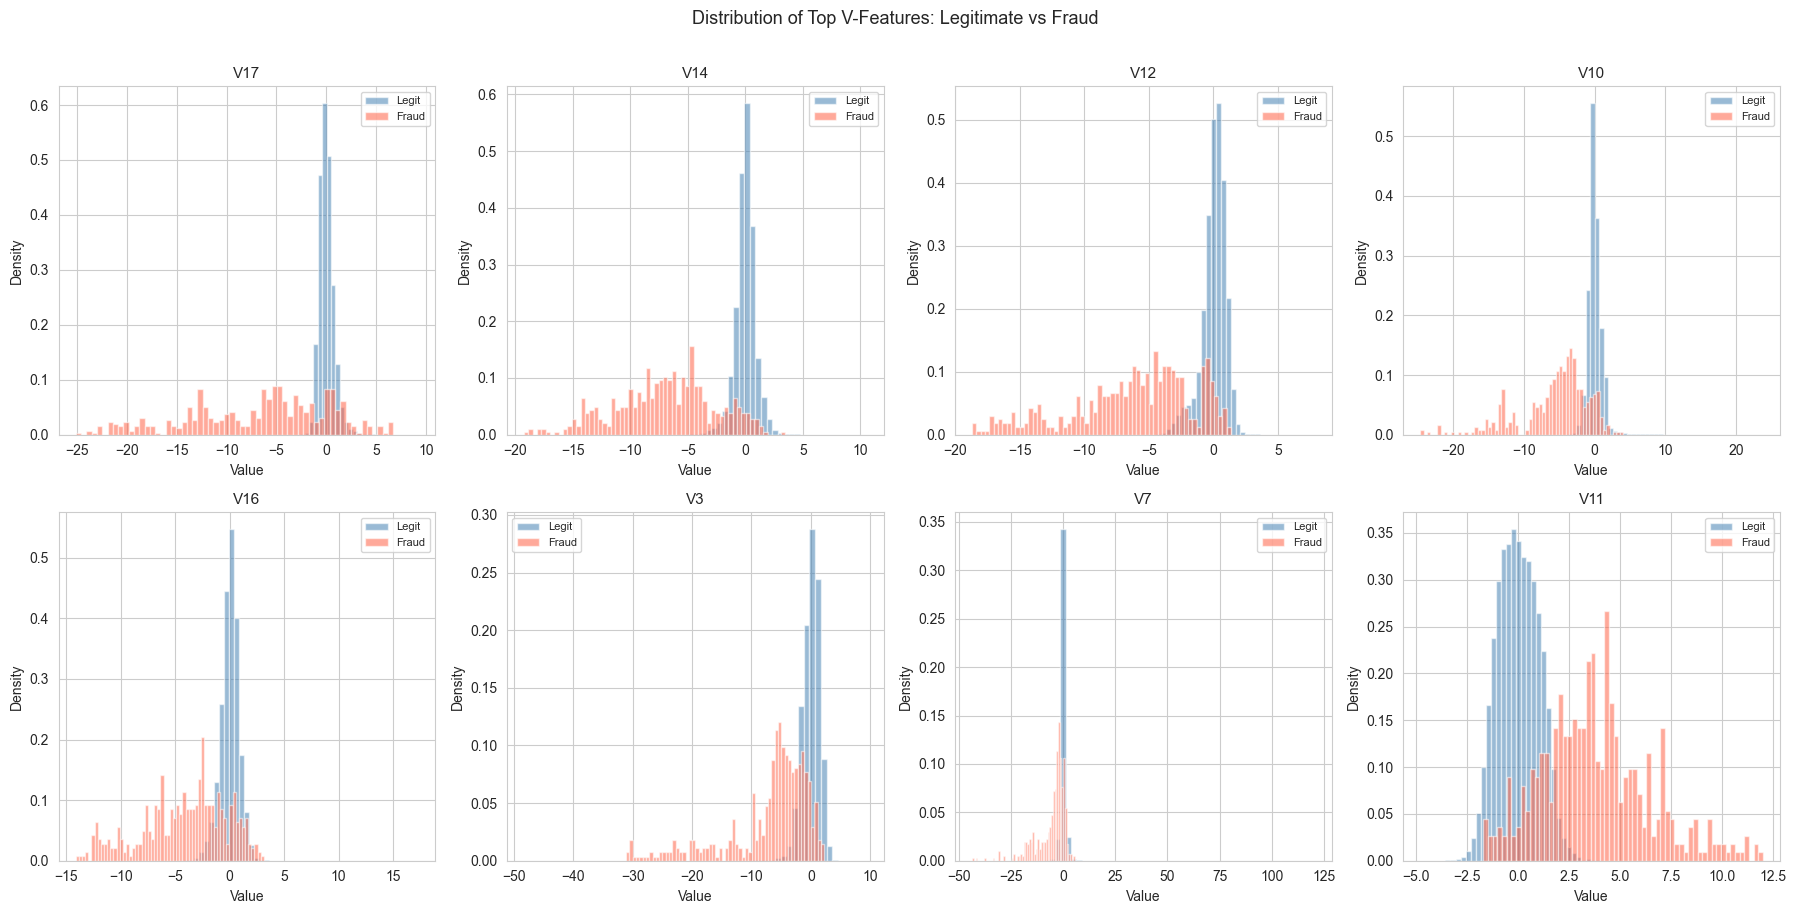

In [50]:
# Compute absolute correlation with Class for each V-feature
v_cols = [f"V{i}" for i in range(1, 29)]
corrs = df[v_cols + ["Class"]].corr()["Class"].drop("Class").abs().sort_values(ascending=False)
top8 = corrs.head(8).index.tolist()
print("Top 8 V-features by |correlation with Class|:")
print(corrs.head(8).round(4))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.flatten(), top8):
    ax.hist(legit[col], bins=60, alpha=0.55, color="steelblue", density=True, label="Legit")
    ax.hist(fraud[col], bins=60, alpha=0.55, color="tomato",    density=True, label="Fraud")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Value"); ax.set_ylabel("Density")
    ax.legend(fontsize=8)
plt.suptitle("Distribution of Top V-Features: Legitimate vs Fraud", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

### V-Feature Distribution Interpretation

The features `V1` to `V28` are anonymized PCA-transformed features, so their exact real-world meanings are not available.

However, some of these features show clear differences between legitimate and fraudulent transactions. In this dataset, features such as `V17`, `V14`, `V12`, and `V10` show stronger correlation with the target variable `Class`.

The distribution plots show that fraud and legitimate transactions have different patterns for several V-features. This means these features may be useful for machine learning models when identifying fraudulent transactions.

Although correlation helps identify important features, correlation alone does not prove causation. The final model should learn from all useful features together.

## 7. Correlation Analysis

We compute the full correlation matrix and separately visualise each feature's correlation with `Class`. Features with high absolute correlation are the most informative for fraud detection.

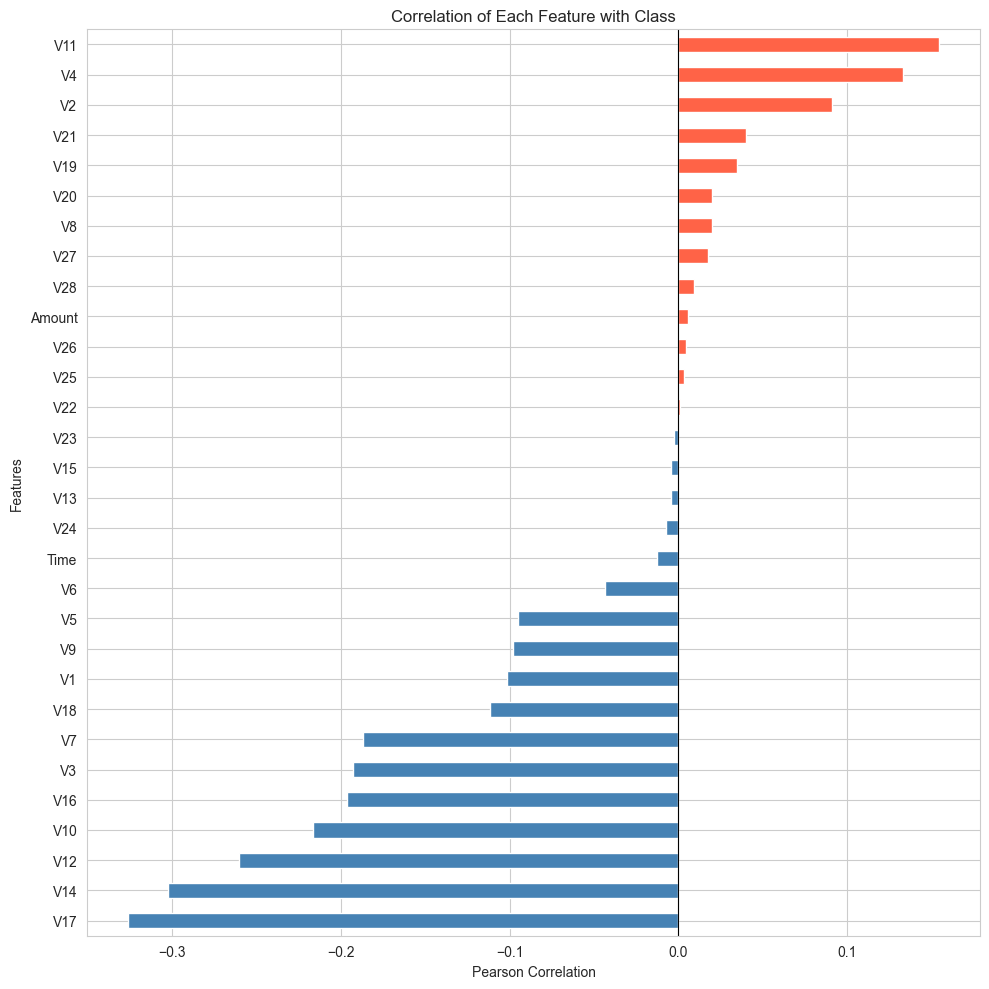

Top 5 Positive Correlations with Fraud


,Feature,Correlation
0,V19,0.034783
1,V21,0.040413
2,V2,0.091289
3,V4,0.133447
4,V11,0.154876


Top 5 Negative Correlations with Fraud


,Feature,Correlation
0,V17,-0.326481
1,V14,-0.302544
2,V12,-0.260593
3,V10,-0.216883
4,V16,-0.196539


In [51]:
# Correlation with target variable Class
target_corr = df.corr(numeric_only=True)["Class"].drop("Class").sort_values()

plt.figure(figsize=(10, 10))

colors = ["tomato" if value > 0 else "steelblue" for value in target_corr]

target_corr.plot(kind="barh", color=colors)

plt.title("Correlation of Each Feature with Class")
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")
plt.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

print("Top 5 Positive Correlations with Fraud")
display(target_corr.tail(5).reset_index().rename(columns={"index": "Feature", "Class": "Correlation"}))

print("Top 5 Negative Correlations with Fraud")
display(target_corr.head(5).reset_index().rename(columns={"index": "Feature", "Class": "Correlation"}))

### Correlation Analysis Interpretation

The correlation analysis shows how each feature is related to the target variable `Class`.

Some features have positive correlation with fraud, while others have negative correlation. A positive correlation means the feature value tends to increase when fraud occurs. A negative correlation means the feature value tends to decrease when fraud occurs.

The PCA-transformed features `V1` to `V28` cannot be interpreted directly because their real-world meanings are anonymized. However, the correlation values still help us understand which features may be more useful for fraud detection.

Features such as `V17`, `V14`, `V12`, and `V10` show stronger relationships with the fraud class. These features may help machine learning models separate fraudulent transactions from legitimate transactions.

Correlation alone does not prove causation, but it gives useful insight before model building.

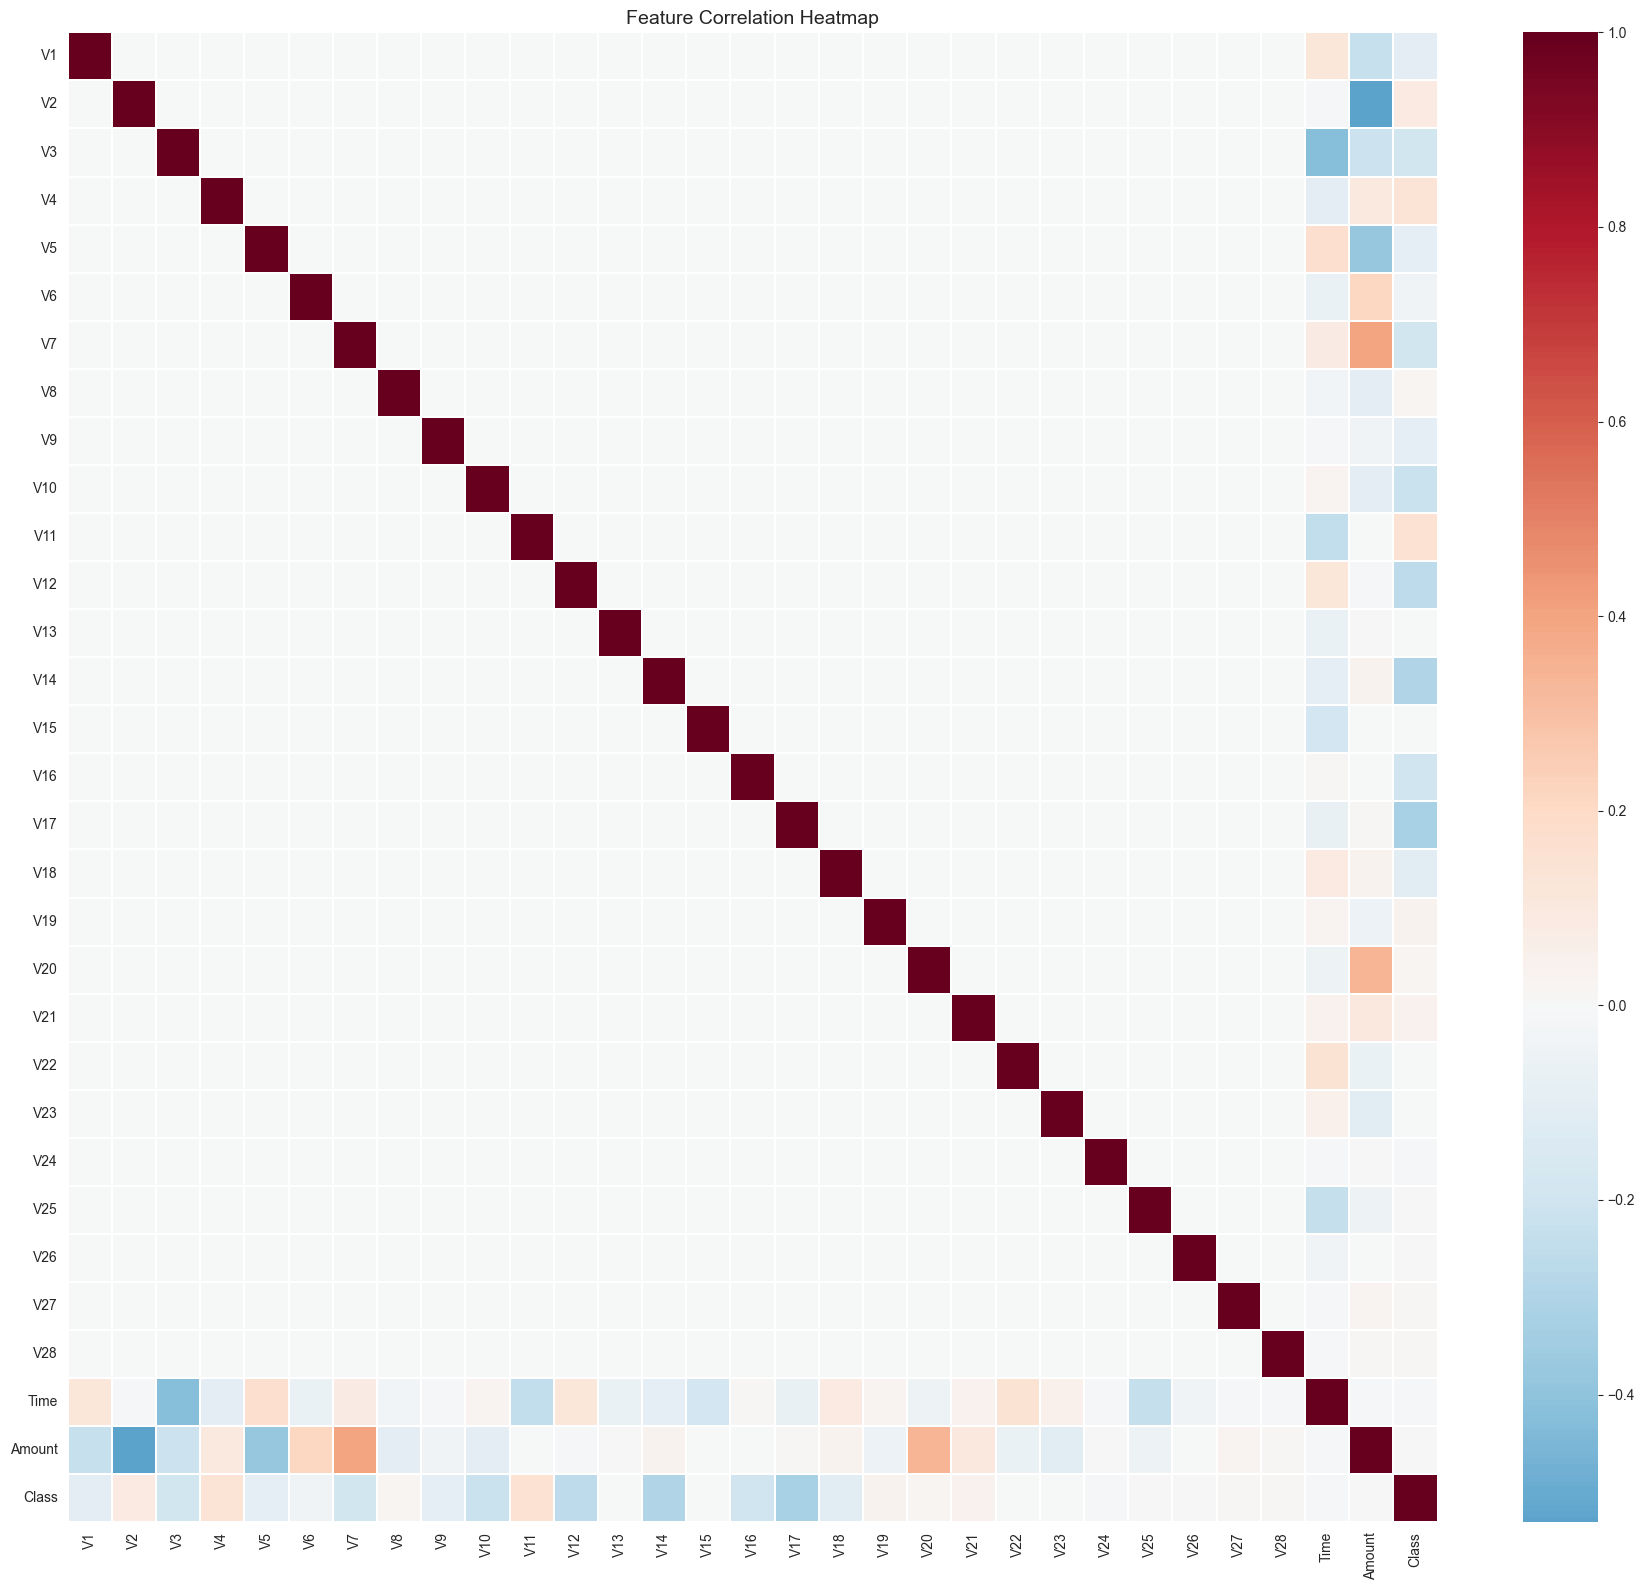

In [52]:
# Full correlation heatmap using V-features, Time, Amount, and Class

v_cols = [f"V{i}" for i in range(1, 29)]

corr_features = v_cols + ["Time", "Amount", "Class"]

plt.figure(figsize=(18, 16))

sns.heatmap(
    df[corr_features].corr(numeric_only=True),
    cmap="RdBu_r",
    center=0,
    annot=False,
    linewidths=0.3
)

plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

### Heatmap Interpretation

The heatmap shows the correlation relationships between the PCA-transformed features, `Time`, `Amount`, and the target variable `Class`.

Most PCA-transformed features have low correlation with each other because PCA creates transformed components. Some features show stronger relationship with the target variable `Class`, which means they may be more useful for fraud detection.

The heatmap is useful for understanding overall feature relationships before model building.

## 8. Summary of Key Findings

Below is a structured summary of the most important observations from the exploratory data analysis.

In [53]:
summary = pd.DataFrame({
    "Finding": [
        "Severe class imbalance",
        "No missing values",
        "1,081 duplicate rows",
        "Amount skew",
        "Fraud amounts smaller on median",
        "Time covers around 48 hours",
        "Important V-features identified",
        "V-features already PCA-scaled",
        "Accuracy is not enough"
    ],
    "Detail": [
        "Only 0.1727% fraud transactions: 492 fraud out of 284,807 total transactions",
        "All 31 columns are complete with no missing values",
        "Duplicate rows will be removed in notebook 02 during data cleaning",
        "Transaction amounts are highly right-skewed, so RobustScaler will be used",
        "Fraud median amount is about 9.25, while legitimate median amount is about 22.00",
        "The Time column records transactions across approximately 48 hours",
        "Features such as V17, V14, V12, and V10 show stronger relationship with fraud",
        "V1 to V28 are PCA-transformed features and will be left unchanged during preprocessing",
        "Because the dataset is highly imbalanced, Precision, Recall, F1-score, ROC-AUC, and confusion matrix are better evaluation metrics"
    ]
})

display(summary)

,Finding,Detail
0,Severe class imbalance,Only 0.1727% fraud transactions: 492 fraud out...
1,No missing values,All 31 columns are complete with no missing va...
2,"1,081 duplicate rows",Duplicate rows will be removed in notebook 02 ...
3,Amount skew,"Transaction amounts are highly right-skewed, s..."
4,Fraud amounts smaller on median,"Fraud median amount is about 9.25, while legit..."
5,Time covers around 48 hours,The Time column records transactions across ap...
6,Important V-features identified,"Features such as V17, V14, V12, and V10 show s..."
7,V-features already PCA-scaled,V1 to V28 are PCA-transformed features and wil...
8,Accuracy is not enough,"Because the dataset is highly imbalanced, Prec..."


## Final EDA Conclusion

The EDA confirms that this is a highly imbalanced fraud detection problem. The dataset has no missing values, but it contains duplicate rows that should be removed before model building.

The `Amount` feature is highly skewed, and the `Time` feature is on a different scale compared to the PCA-transformed features. Therefore, `Amount` and `Time` will be scaled during preprocessing.

The PCA-transformed features `V1` to `V28` already contain useful fraud detection patterns. Some features, especially `V17`, `V14`, `V12`, and `V10`, show stronger separation between legitimate and fraudulent transactions.

Because fraud cases are very rare, model performance should not be judged using accuracy alone. In the model building stage, evaluation should focus on Precision, Recall, F1-score, ROC-AUC, and confusion matrix.